In [11]:
from scipy.optimize import minimize # finding optimal params in models
from scipy import stats             # statistical tools
import numpy as np                  # matrix/array functions
import pandas as pd                 # loading and manipulating data
import ipywidgets as widgets        # interactive display
import matplotlib.pyplot as plt     # plotting
import os
%matplotlib inline
import learning_models as lm
import analysis_functions

subject_id = 3
np.random.seed(2021)                # set seed for reproducibility

In [12]:
# Make output folder
output_plot_dir = os.path.join('..','plots','learning_models')
if not os.path.exists(output_plot_dir):
    os.makedirs(output_plot_dir)

output_file_dir = os.path.join('..','pre-processed')
if not os.path.exists(output_file_dir):
    os.makedirs(output_file_dir)

In [13]:
# Locate and load sequence_path
experiment_output_path = os.path.join('..','..','phd_1_task','experiment_output')
recent_results = analysis_functions.list_files_with_date_and_subject_id(experiment_output_path)

## Unlist sequence_path
sequence_path = [i for i in recent_results if f'sub-{subject_id:003}' in i]
sequence_path = (lambda x: x)(*sequence_path)

In [14]:
# Load probability sequence
original_dataframe = pd.read_csv(sequence_path)
original_dataframe['probability_condition'] = original_dataframe['probability_condition'].div(100).round(2)

# Replace responses
mapping = {'up': 1, 'down': 0}
original_dataframe['response'] = original_dataframe['response'].replace(mapping)
original_dataframe['response'] = original_dataframe['response'].astype('float')

stimuli_types = [1,2,3,4]

## Reorganise into a dataframe containing only the probability sequences
probability_dataframe = pd.DataFrame()
for i, stimuli_type in enumerate(stimuli_types):
    filtered_dataframe = (original_dataframe.loc[original_dataframe['stimuli_type'] == stimuli_type]).reset_index()
    probability_dataframe[f'stimuli_type_{stimuli_type}'] = filtered_dataframe['probability_condition']
print(probability_dataframe)

     stimuli_type_1  stimuli_type_2  stimuli_type_3  stimuli_type_4
0               0.5             0.5             0.5             0.5
1               0.5             0.5             0.5             0.5
2               0.5             0.5             0.8             0.5
3               0.5             0.5             0.8             0.5
4               0.2             0.2             0.8             0.2
..              ...             ...             ...             ...
115             0.2             0.8             0.8             0.8
116             0.2             0.8             0.8             0.8
117             0.2             0.8             0.8             0.8
118             0.2             0.8             0.8             0.8
119             0.2             0.8             0.8             0.8

[120 rows x 4 columns]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3474/3068302754.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  original_dataframe['response'] = original_dataframe['response'].replace(mapping)


In [15]:
# Set variables needed for all models
trials = 120
K = 2
mu = [0.2, 0.8]

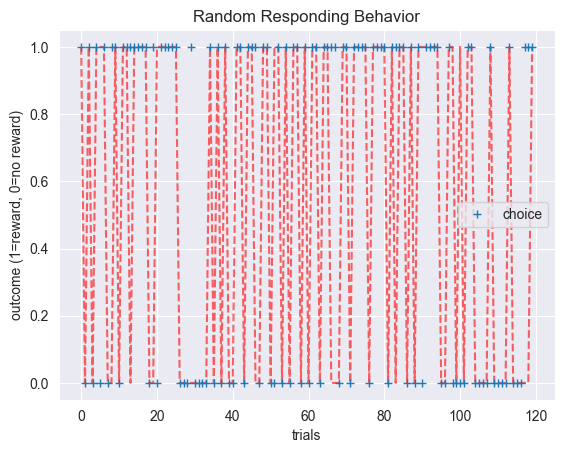

In [16]:
# simulate the random responding model and plot the results
choices_1, responses_1 = lm.simulate_random_responders(bias=.5, trials=trials, mu=mu)

## Plot the simulation
plt.plot(range(trials), responses_1, 'r--', alpha=.6)
plt.plot(range(trials), choices_1, '+', label='choice')
plt.xlabel('trials')
plt.ylabel('outcome (1=reward, 0=no reward)')
plt.title(f'Random Responding Behavior')
plt.legend()
plt.show()

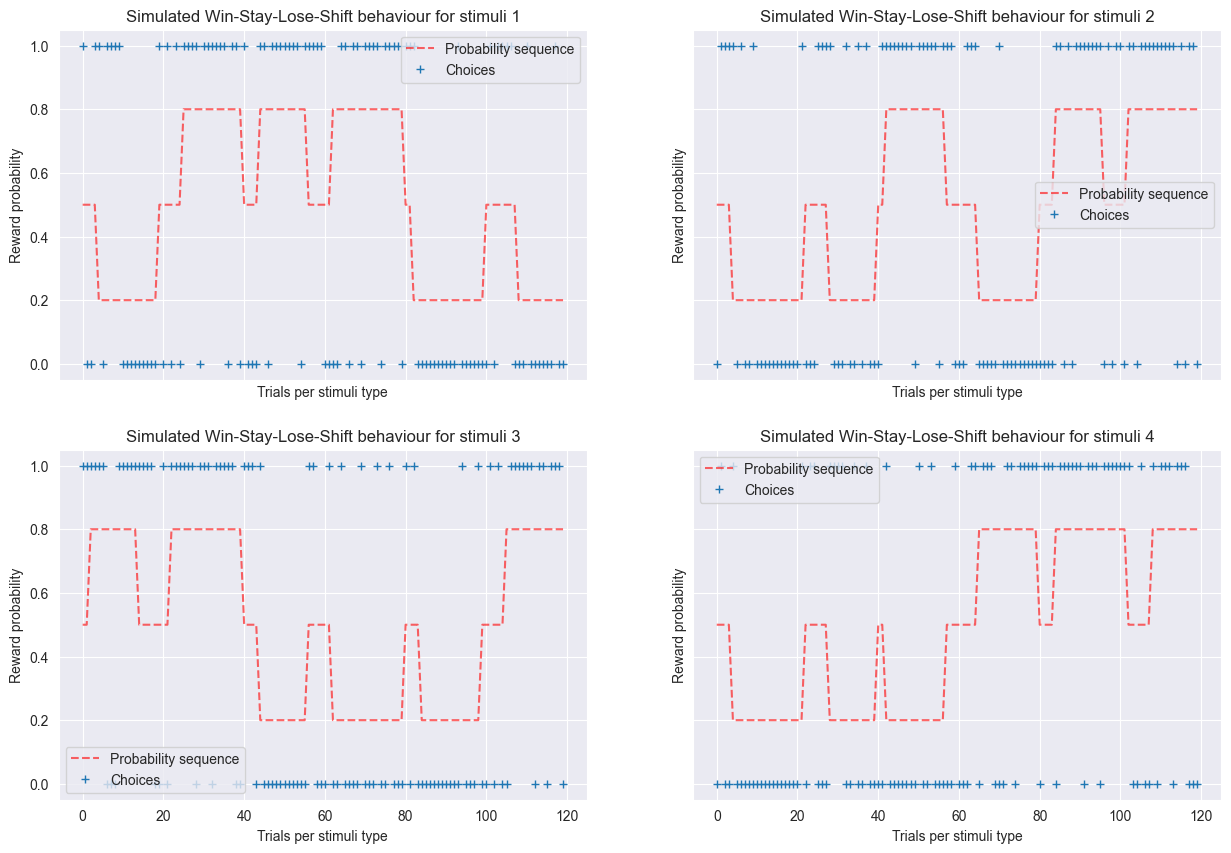

In [17]:
# Create plot with subplots
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

responses_dataframe = pd.DataFrame()

# Loop through all stimuli_types to create subplots
for i, stimuli_type in enumerate(stimuli_types):
    
    # Turn pandas column to list
    mu_sequence = probability_dataframe[f'stimuli_type_{stimuli_type}'].tolist()
    
    # Run the WSLS simulation
    choices_2, responses_2 = lm.simulate_win_stay_lose_shift(epsilon=.1, trials=trials, mu_sequence=mu_sequence)
    
    ## Plot the WSLS simulation
    axs[i].plot(range(trials), mu_sequence, 'r--', alpha=.6, label='Probability sequence')
    axs[i].plot(range(trials), choices_2, '+', label='Choices')
    axs[i].set_xlabel('Trials per stimuli type')
    axs[i].set_ylabel('Reward probability')
    axs[i].set_title(f'Simulated Win-Stay-Lose-Shift behaviour for stimuli {stimuli_type}')
    axs[i].legend()

    # Save responses of the model and the participant
    filtered_dataframe = (original_dataframe.loc[original_dataframe['stimuli_type'] == stimuli_type]).reset_index()
    responses_dataframe[f'participant_responses_stimuli_{stimuli_type}'] = filtered_dataframe['response']
    responses_dataframe[f'WSLS_model_responses_stimuli_{stimuli_type}'] = choices_2

plt.savefig(os.path.join(output_plot_dir, f'simulated_wsls_behaviour_sub-{subject_id:-003}.pdf'))
plt.show()

responses_dataframe.to_csv(os.path.join(output_file_dir,f'responses_models_and_sub-{subject_id:003}.csv'))

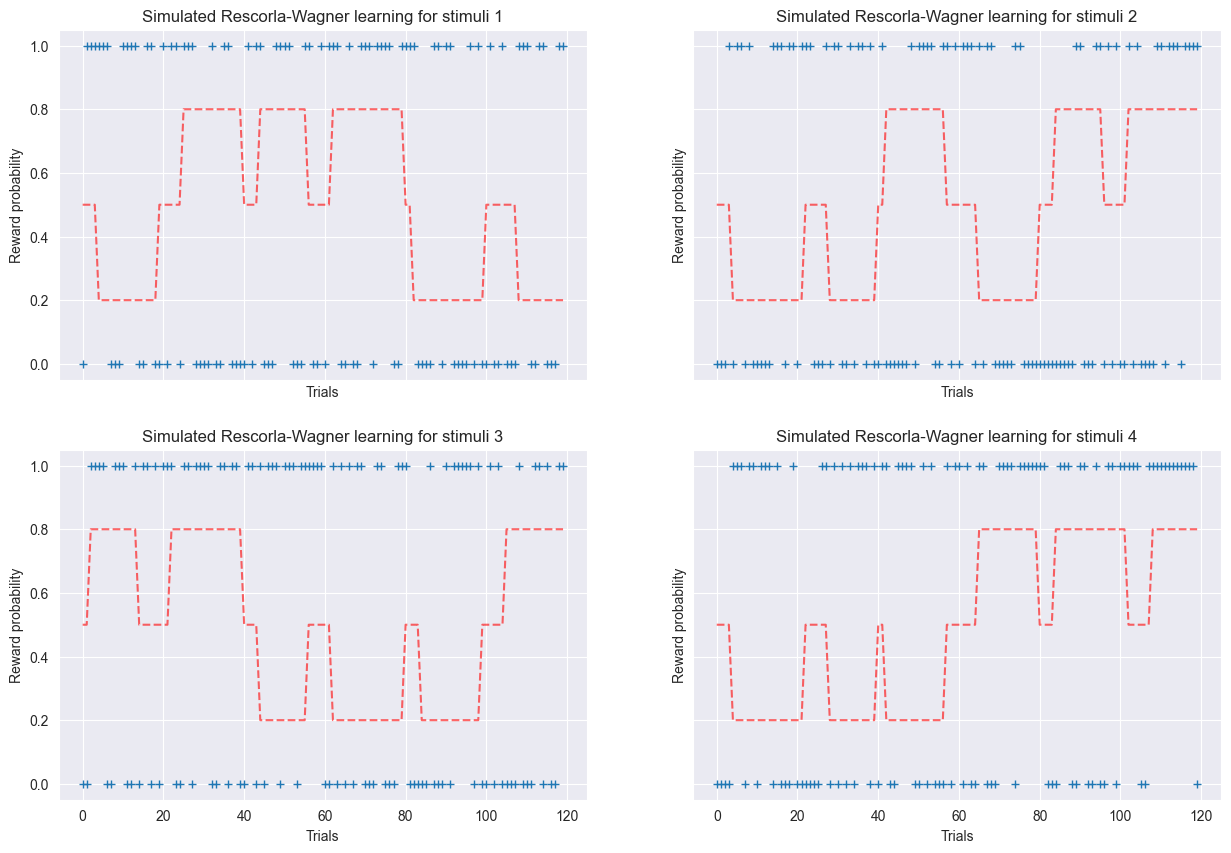

In [18]:
# Create plot with subplots
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

# Loop through all stimuli_types to create subplots
for i, stimuli_type in enumerate(stimuli_types):

    # Turn pandas column to list
    mu_sequence = probability_dataframe[f'stimuli_type_{stimuli_type}'].tolist()
    
    # Run model
    choices_3, responses_3, Q = lm.simulate_rescorla_wagner(alpha=.1, theta=1.5, trials=trials, mu_sequence=mu_sequence)

    # plot the simulation
    axs[i].plot(range(trials), mu_sequence, 'r--', alpha=.6)
    axs[i].plot(range(trials), choices_3, '+', label='choice')
    axs[i].set_xlabel('Trials')
    axs[i].set_ylabel('Reward probability')
    axs[i].set_title(f'Simulated Rescorla-Wagner learning for stimuli {stimuli_type}')

plt.savefig(os.path.join(output_plot_dir, f'simulated_rescorla_wagner_learning_sub-{subject_id:-003}.pdf'))
plt.show()

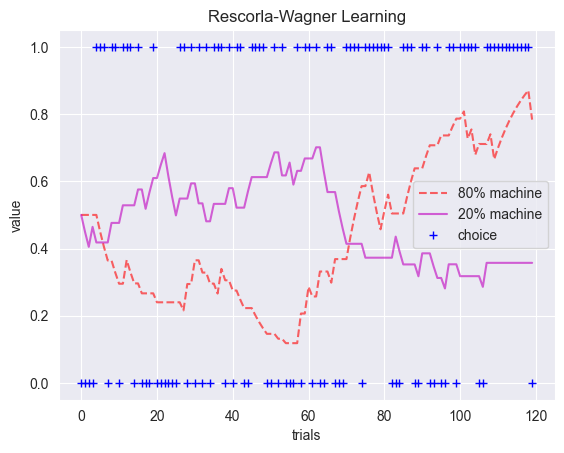

In [19]:
# plot the simulation
plt.plot(range(trials), Q[1,:], 'r--', alpha=.6, label='80% machine')
plt.plot(range(trials), Q[0,:], 'm-', alpha=.6, label='20% machine')
plt.plot(range(trials), choices_3, 'b+', label='choice')
plt.xlabel('trials')
plt.ylabel('value')
plt.title(f'Rescorla-Wagner Learning')
plt.legend()
plt.show()

In [20]:
# Check correspondance between button presses of model and participants, 